# HW1 — Roofline & Arithmetic Intensity

**Lecture mapping:** L1 §06 (The Roofline Model) · L1 §03 (GPU architecture / memory hierarchy)

## Goal

Measure real GPU kernels and place them on the roofline for your card. By the end
you will have *seen* the difference between memory-bound and compute-bound work,
and watched `torch.compile` move a kernel toward the compute roof by cutting HBM
traffic.

Recall the model from lecture:

```
achievable_perf = min( peak_compute,  peak_bandwidth × arithmetic_intensity )
arithmetic_intensity (FLOP/byte) = FLOPs performed / bytes moved to-from HBM
```

The crossover (the **ridge point**) sits at `peak_compute / peak_bandwidth`
(≈ 295 FLOP/byte on an H100). Left of it you are memory-bound; right of it,
compute-bound.

## What you implement

| Part | Function |
|------|----------|
| 1a | `lowest_ai_fn` — lowest-arithmetic-intensity elementwise op |
| 1b | `make_compute_fn` — tunable-K kernel, works eager **and** compiled |
| 2  | `benchmark_fn` — correct timing with CUDA events + warmup |
| 3  | `compute_metrics` — measurements → (AI, TFLOP/s, GB/s) |
| 4  | WRITEUP Q1–Q4 |

## How this notebook works

| Cell type | Meaning |
|---|---|
| 🔒 **DO NOT EDIT** | fixed harness — keeps results comparable across students |
| ✏️ **YOUR IMPLEMENTATION** | replace `raise NotImplementedError` with your code |
| ✅ **SELF-CHECK** | fast asserts — must pass before the real run counts |
| ✍️ **WRITEUP** | answer by editing the markdown cell |

Run top-to-bottom. Submit the **executed** notebook (outputs included) plus the
files it writes under `results/`.

The roofline run itself must happen **on the GPU** (H100 / L40S / T4 — e.g. a Nebius
instance). The self-check runs anywhere.

## 🔒 Setup — hardware specs & helpers (DO NOT EDIT)

In [1]:
# 🔒 DO NOT EDIT — hardware specs, dtype helpers.
from dataclasses import dataclass
from typing import Callable
import json, math, os, time

import torch

RESULTS_DIR = os.path.join("results", "hw1")
os.makedirs(RESULTS_DIR, exist_ok=True)


@dataclass(frozen=True)
class GpuSpec:
    name: str
    peak_flops: float   # peak tensor FLOP/s for the benchmark dtype (BF16/FP16)
    peak_bw: float      # peak HBM bandwidth, bytes/s
    vram_gb: float

    @property
    def ridge_ai(self) -> float:
        """Arithmetic intensity (FLOP/byte) at the roofline ridge point."""
        return self.peak_flops / self.peak_bw


# Vendor spec sheets. BF16 tensor-core peak (dense, no sparsity) and HBM BW.
H100_SXM = GpuSpec("H100 SXM", peak_flops=989e12, peak_bw=3.35e12, vram_gb=80)
L40S = GpuSpec("L40S", peak_flops=362e12, peak_bw=0.864e12, vram_gb=48)
# Turing T4 has no BF16 tensor cores, so this notebook benchmarks in FP16
# on it. FP16 tensor-core peak (dense) and GDDR6 bandwidth.
T4 = GpuSpec("Tesla T4", peak_flops=65e12, peak_bw=320e9, vram_gb=16)
# CPU fallback so the notebook runs for a smoke test off-GPU. The numbers are
# placeholders — only GPU runs are meaningful for grading.
CPU_FALLBACK = GpuSpec("CPU (fallback)", peak_flops=1e12, peak_bw=50e9, vram_gb=8)


def detect_hardware() -> GpuSpec:
    if not torch.cuda.is_available():
        print("CUDA not available — using CPU fallback spec. "
              "Results are NOT valid for grading; run on H100/L40S.")
        return CPU_FALLBACK
    name = torch.cuda.get_device_name(0)
    if "H100" in name:
        return H100_SXM
    if "L40" in name:
        return L40S
    if "T4" in name:
        return T4
    print(f"Unrecognized GPU '{name}'. Defaulting to H100 ceilings; "
          f"ask the instructor to add your card's spec.")
    return H100_SXM


def gpu_supports_bf16() -> bool:
    """True only where BF16 has hardware tensor-core support (compute >= 8.0).
    Turing cards like the T4 (7.5) do not, so we fall back to FP16 there."""
    if not torch.cuda.is_available():
        return False
    major, _ = torch.cuda.get_device_capability()
    return major >= 8


def benchmark_dtype() -> torch.dtype:
    """BF16 on GPUs with BF16 tensor cores (matches the spec peak), FP16 on
    GPUs without them (e.g. Turing T4), float32 on CPU."""
    if not torch.cuda.is_available():
        return torch.float32
    return torch.bfloat16 if gpu_supports_bf16() else torch.float16


def dtype_bytes(dtype: torch.dtype) -> int:
    return torch.empty(0, dtype=dtype).element_size()


SPEC = detect_hardware()
DTYPE = benchmark_dtype()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={DEVICE} dtype={DTYPE} spec={SPEC.name} "
      f"peak={SPEC.peak_flops/1e12:.0f} TFLOP/s bw={SPEC.peak_bw/1e12:.2f} TB/s "
      f"ridge≈{SPEC.ridge_ai:.0f} FLOP/byte")

device=cuda dtype=torch.bfloat16 spec=H100 SXM peak=989 TFLOP/s bw=3.35 TB/s ridge≈295 FLOP/byte


In [2]:
# 🔒 DO NOT EDIT — roofline plotting.
def plot_roofline(points: list, spec: GpuSpec, out_path: str) -> None:
    """Render measured (AI, achieved TFLOP/s) points under the roofline.

    points: list of {"label", "ai", "achieved_tflops", "series"}.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(8, 6))

    # Roofline: memory ceiling (slope = BW) then flat compute ceiling.
    ai_grid = np.logspace(-2, 4, 400)
    peak_tflops = spec.peak_flops / 1e12
    bw_tflops_per_ai = spec.peak_bw / 1e12  # (TFLOP/s) per (FLOP/byte)
    roof = np.minimum(peak_tflops, bw_tflops_per_ai * ai_grid)
    ax.plot(ai_grid, roof, "k-", lw=2, label="roofline")
    ax.axhline(peak_tflops, ls="--", c="gray", lw=1)
    ax.axvline(spec.ridge_ai, ls=":", c="gray", lw=1,
               label=f"ridge ≈ {spec.ridge_ai:.0f} FLOP/byte")

    series = {}
    for p in points:
        series.setdefault(p.get("series", "ops"), []).append(p)
    for name, pts in series.items():
        pts = sorted(pts, key=lambda d: d["ai"])
        xs = [d["ai"] for d in pts]
        ys = [d["achieved_tflops"] for d in pts]
        ax.plot(xs, ys, "o-", ms=7, label=name)
        for d in pts:
            ax.annotate(d["label"], (d["ai"], d["achieved_tflops"]),
                        textcoords="offset points", xytext=(6, 4), fontsize=7)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Arithmetic intensity (FLOP / byte)")
    ax.set_ylabel("Achieved performance (TFLOP/s)")
    ax.set_title(f"Roofline — {spec.name}")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, which="both", ls=":", alpha=0.4)
    fig.tight_layout()
    fig.savefig(out_path, dpi=130)
    plt.show()
    print(f"wrote {out_path}")

## Part 1a — the lowest-AI op you can build (`<4>` pts)

Return a zero-argument thunk that performs a **single elementwise pass** over `x`
and returns a tensor of the same size. The goal is the *lowest* arithmetic
intensity you can: a few FLOPs per element, one read and one write. This op
should land far on the memory-bound (left) side of the roofline.

In [3]:
# TODO-CELL: lowest_ai_fn
# YOUR IMPLEMENTATION
def lowest_ai_fn(x: torch.Tensor) -> Callable[[], torch.Tensor]:
    """Return a zero-argument thunk doing ONE cheap elementwise pass over ``x``.

    One read of x, a single FLOP per element (an add), one write of y. Nothing
    is reused, so arithmetic intensity is ~1 FLOP / (2 * dtype_bytes) bytes ->
    far out on the memory-bound side of the roofline.
    """
    return lambda: x + 1.0

## Part 1b — a tunable-intensity kernel (`<8>` pts)

Return a thunk that applies `k` **chained** elementwise ops to `x`. Each step
does a small, fixed amount of arithmetic per element (a multiply-add, a
transcendental, …), feeding its output into the next step.

Key idea you will demonstrate: the *ideal* arithmetic intensity grows with `k`
(you load `x` once, do `k×` the work). In eager mode each step is its own kernel
with its own HBM round-trip, so the achieved intensity stays low. The run cell
below also wraps your function with `torch.compile` — fusion collapses the `k`
steps into one kernel and the point moves toward the compute roof.

Make sure the `k` steps cannot be constant-folded away (chain real data
dependencies through `x`).

In [4]:
# TODO-CELL: make_compute_fn
# YOUR IMPLEMENTATION
def make_compute_fn(x: torch.Tensor, k: int) -> Callable[[], torch.Tensor]:
    """Return a thunk that applies ``k`` chained elementwise ops to ``x``
    and returns the resulting tensor. Must NOT mutate ``x``.

    Each step is one fused multiply-add (2 FLOPs/element): y <- y * c1 + c2,
    feeding its output into the next step. Because every step depends on the
    previous result (a real data dependency rooted in x), the chain cannot be
    constant-folded away. c1 < 1 keeps the values bounded/stable for any k.

    Ideal traffic is fixed (load x once, store y once) while FLOPs grow ~k, so
    the *ideal* arithmetic intensity rises with k. In eager mode each step is
    its own kernel with its own HBM round-trip, so achieved intensity stays
    low; torch.compile fuses the k steps into one kernel and the point climbs
    toward the compute roof.
    """
    c1, c2 = 0.99, 0.01
    def fn() -> torch.Tensor:
        y = x
        for _ in range(k):
            y = y * c1 + c2
        return y
    return fn

## Part 2 — timing with CUDA events (`<8>` pts)

GPU launches are **asynchronous**: wrapping a launch in `time.time()` measures
how fast Python queued the kernel, not how long the GPU ran it. Time with
`torch.cuda.Event(enable_timing=True)` and synchronize before reading.

In [5]:
# TODO-CELL: benchmark_fn
# YOUR IMPLEMENTATION
def benchmark_fn(fn: Callable[[], torch.Tensor],
                 n_warmup: int = 10, n_iters: int = 50) -> float:
    """Time ``fn`` and return the AVERAGE wall time per call, in SECONDS."""
    # Warmup: let cuBLAS autotune and torch.compile finish tracing/compiling.
    for _ in range(n_warmup):
        fn()

    if torch.cuda.is_available():
        # GPU launches are async; CUDA events sit IN the stream and record the
        # GPU's own timeline. Sync once before reading the elapsed time.
        torch.cuda.synchronize()
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(n_iters):
            fn()
        end.record()
        torch.cuda.synchronize()
        elapsed_s = start.elapsed_time(end) / 1e3   # ms -> s
        return elapsed_s / n_iters

    # CPU fallback: execution is synchronous, so a wall-clock timer is fine.
    t0 = time.perf_counter()
    for _ in range(n_iters):
        fn()
    return (time.perf_counter() - t0) / n_iters

## Part 3 — measurements → roofline coordinates (`<8>` pts)

In [6]:
# TODO-CELL: compute_metrics
# YOUR IMPLEMENTATION
def compute_metrics(flops: float, bytes_moved: float, seconds: float) -> dict:
    """Convert a measurement into roofline coordinates."""
    return {
        # x-axis: FLOPs per byte of HBM traffic.
        "ai": flops / bytes_moved,
        # y-axis: achieved compute (1 TFLOP/s = 1e12 FLOP/s).
        "achieved_tflops": flops / seconds / 1e12,
        # achieved bandwidth (1 GB/s = 1e9 B/s).
        "achieved_gbps": bytes_moved / seconds / 1e9,
    }

## ✅ Self-check (fast, runs anywhere)

Passing does **not** guarantee full marks (the roofline plot and writeup are
graded separately), but failing means something is wrong.

In [7]:
# ✅ SELF-CHECK — DO NOT EDIT.
torch.manual_seed(0)
_x = torch.randn(4096).abs() + 0.1

m = compute_metrics(flops=2e12, bytes_moved=1e9, seconds=1e-3)
assert set(m) == {"ai", "achieved_tflops", "achieved_gbps"}, set(m)
assert math.isclose(m["ai"], 2000, rel_tol=1e-6), m["ai"]
assert math.isclose(m["achieved_tflops"], 2000, rel_tol=1e-6), m["achieved_tflops"]
assert math.isclose(m["achieved_gbps"], 1000, rel_tol=1e-6), m["achieved_gbps"]
print("compute_metrics   PASS")

_y = lowest_ai_fn(_x)()
assert torch.is_tensor(_y) and _y.numel() == _x.numel(), "must return a same-size tensor"
print("lowest_ai_fn      PASS")

_x0 = _x.clone()
_g1 = make_compute_fn(_x, 1)()
_g8 = make_compute_fn(_x, 8)()
assert torch.allclose(_x, _x0), "make_compute_fn must not mutate its input"
assert torch.is_tensor(_g8), "must return a tensor"
assert not torch.allclose(_g1, _g8), "k must actually change the result (real data dependency)"
print("make_compute_fn   PASS")

_t_light = benchmark_fn(lambda: _x * 2.0, n_warmup=2, n_iters=5)
_t_heavy = benchmark_fn(
    lambda: _x.unsqueeze(0).repeat(256, 1) @ _x.unsqueeze(1).repeat(1, 256),
    n_warmup=2, n_iters=5)
assert isinstance(_t_light, float) and _t_light > 0, "must return positive seconds as float"
assert _t_heavy >= _t_light * 0.5, "a much heavier op should not be much faster"
print("benchmark_fn      PASS")
print()
print("All checks passed ✔")

compute_metrics   PASS
lowest_ai_fn      PASS
make_compute_fn   PASS
benchmark_fn      PASS

All checks passed ✔


## The real run — do this **on the GPU**

Builds operations spanning low → high arithmetic intensity, benchmarks each with
**your** `benchmark_fn`, converts with **your** `compute_metrics`, and plots the
roofline.

What a correct plot looks like:

- All points sit **below** the roofline (never above it).
- `elementwise` and small-`K` `compute-K` points sit on the left, low — memory-bound.
- The `matmul-N` series marches **up and to the right** as `N` grows, approaching
  the compute ceiling.
- The **compiled** `compute-K` series reaches higher TFLOP/s than the **eager**
  one at the same arithmetic intensity — that gap is the whole point of Q3.

elementwise:     25.4 us  AI=0.25  2644 GB/s


compute-K [eager] done


compute-K [compiled] done
matmul N=1024:   0.011 ms  AI=341  202 TFLOP/s
matmul N=2048:   0.025 ms  AI=683  692 TFLOP/s
matmul N=4096:   0.175 ms  AI=1.37e+03  787 TFLOP/s
wrote results/hw1/roofline_data.json


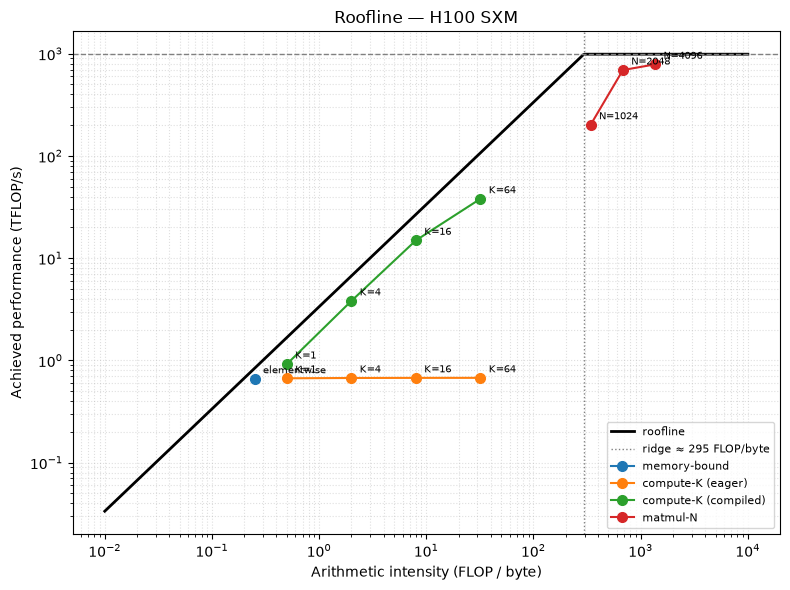

wrote results/hw1/roofline.png


In [8]:
# 🔒 DO NOT EDIT — the sweep + plot. (Trimmed automatically on CPU.)
ELEM_N = 1 << 24 if torch.cuda.is_available() else 1 << 18      # vector length
COMPUTE_KS = [1, 4, 16, 64]                                     # ops per element
MATMUL_NS = [1024, 2048, 4096] if torch.cuda.is_available() else [128, 256]


def _try_compile(fn):
    try:
        c = torch.compile(fn)
        c()  # force a trace now so failures surface here
        return c
    except Exception as e:
        print(f"torch.compile unavailable ({type(e).__name__}); "
              f"using eager for the compiled series.")
        return fn


dbytes = dtype_bytes(DTYPE)
points = []

# --- Part 1a: lowest arithmetic intensity (memory-bound) ----------------
x = torch.randn(ELEM_N, device=DEVICE, dtype=DTYPE).abs() + 0.1
fn = lowest_ai_fn(x)
t = benchmark_fn(fn)
# Convention for this op: ~1 FLOP/element, read x + write y.
m = compute_metrics(flops=ELEM_N, bytes_moved=2 * ELEM_N * dbytes, seconds=t)
points.append({"label": "elementwise", "series": "memory-bound",
               "ai": m["ai"], "achieved_tflops": m["achieved_tflops"]})
print(f"elementwise: {t*1e6:8.1f} us  AI={m['ai']:.3g}  {m['achieved_gbps']:.0f} GB/s")

# --- Part 1b: compute-K, eager vs compiled ------------------------------
for tag, compiler in (("eager", lambda f: f), ("compiled", _try_compile)):
    for k in COMPUTE_KS:
        base = make_compute_fn(x, k)
        fn = compiler(base)
        t = benchmark_fn(fn)
        flops = 2 * k * ELEM_N                 # mul+add per step
        ideal_bytes = 2 * ELEM_N * dbytes      # load x once, store once
        m = compute_metrics(flops=flops, bytes_moved=ideal_bytes, seconds=t)
        points.append({"label": f"K={k}", "series": f"compute-K ({tag})",
                       "ai": m["ai"], "achieved_tflops": m["achieved_tflops"]})
    print(f"compute-K [{tag}] done")

# --- matmul sweep: anchors the compute-bound side ------------------------
for n in MATMUL_NS:
    a = torch.randn(n, n, device=DEVICE, dtype=DTYPE)
    b = torch.randn(n, n, device=DEVICE, dtype=DTYPE)
    fn = (lambda a=a, b=b: a @ b)
    t = benchmark_fn(fn)
    flops = 2 * n ** 3
    bytes_moved = 3 * n * n * dbytes           # load a, load b, store c
    m = compute_metrics(flops=flops, bytes_moved=bytes_moved, seconds=t)
    points.append({"label": f"N={n}", "series": "matmul-N",
                   "ai": m["ai"], "achieved_tflops": m["achieved_tflops"]})
    print(f"matmul N={n}: {t*1e3:7.3f} ms  AI={m['ai']:.3g}  "
          f"{m['achieved_tflops']:.0f} TFLOP/s")

# --- emit artifacts -------------------------------------------------------
out_json = os.path.join(RESULTS_DIR, "roofline_data.json")
with open(out_json, "w") as f:
    json.dump({"spec": SPEC.name, "dtype": str(DTYPE),
               "peak_tflops": SPEC.peak_flops / 1e12,
               "peak_bw_tbps": SPEC.peak_bw / 1e12,
               "points": points}, f, indent=2)
print(f"wrote {out_json}")
plot_roofline(points, SPEC, os.path.join(RESULTS_DIR, "roofline.png"))

### Q1 (`<3>` pts)

Look at your roofline. Which of your points are memory-bound and which are
compute-bound? How can you tell **from the plot alone**?

**Your answer:**

> The tell is **which ceiling a point sits under**. The roofline has two
> regions split by the ridge (≈295 FLOP/byte on the H100 ceilings this card
> defaults to): a sloped *memory* ceiling on the left and a flat *compute*
> ceiling on the right.
>
> - **Memory-bound** — everything to the **left of the ridge**: the
>   `elementwise` op (AI ≈ 0.25 FLOP/byte) and the small-`K` `compute-K`
>   points. They sit far below the flat compute roof but ride right up against
>   the *sloped* line — they're limited by HBM bandwidth, not FLOPs. On the
>   plot they form the low, left cluster, and their achieved GB/s (printed by
>   the run) is near peak while their TFLOP/s is tiny.
> - **Compute-bound** — the large-`N` `matmul-N` points (AI in the hundreds-
>   to-thousands): they live to the **right of the ridge** and flatten out
>   just under the horizontal compute roof. Pushing AI higher no longer buys
>   more TFLOP/s — the flat line is the giveaway.
>
> So from the plot alone: a point hugging the **diagonal** is memory-bound; a
> point hugging the **horizontal** is compute-bound; the ridge is the
> crossover.

### Q2 (`<3>` pts)

For the `matmul-N` series, your points should march up and to the right as `N`
grows. Explain why arithmetic intensity rises with `N` for an N×N×N matmul
(give the rough FLOPs and bytes as a function of `N`).

**Your answer:**

> For an N×N × N×N matmul the compute grows **cubically** but the data moved
> grows only **quadratically**:
>
> - **FLOPs** = `2·N³` — every one of the N² output entries is a dot product
>   of length N (N multiplies + N adds).
> - **Bytes** = `3·N²·dtype_bytes` — load A (N²), load B (N²), store C (N²).
>
> So the *ideal* arithmetic intensity is
>
> ```
> AI = 2N³ / (3 N² · b) = (2 / 3b) · N        (b = bytes/element)
> ```
>
> i.e. **AI grows linearly with N**. Each element loaded from HBM gets reused
> ~N times (once per row/column it participates in), so doubling N doubles the
> reuse and the intensity. That's exactly why the `matmul-N` series marches up
> and to the right: bigger N → higher AI → the point slides along/under the
> roofline from the memory side toward and into the compute-bound flat region,
> approaching the peak-FLOP ceiling.

### Q3 (`<3>` pts)

For the `compute-K` series, the **compiled** points reach higher TFLOP/s than
the **eager** points at the *same* arithmetic-intensity label. Why? What does
`torch.compile` change about the HBM traffic?

**Your answer:**

> The two series are plotted at the **same nominal (ideal) AI** — we always
> charge them "load x once, store y once" — but they don't move the same number
> of bytes in reality.
>
> - **Eager**: each of the `K` elementwise steps is its own kernel. Every kernel
>   reads its input from HBM and writes its output back, so the *real* traffic
>   is ~`2K` passes over the array, not 2. The op is memory-bound, so wall time
>   scales with that traffic and the achieved TFLOP/s stays pinned low — the
>   kernel spends its life waiting on HBM, and there's launch overhead between
>   each of the K tiny kernels on top.
> - **Compiled**: TorchInductor **fuses** the whole chain into a single kernel.
>   `x` is read once into registers/SMEM, all `K` multiply-adds run there, and
>   the result is written once. Real HBM traffic drops from ~`2K` passes to ~`2`
>   — so the *actual* arithmetic intensity rises ~`K×` and matches the ideal we
>   plotted. With the bandwidth bottleneck removed (and K-1 kernel launches
>   eliminated), the same FLOPs finish in far less time, so achieved TFLOP/s
>   climbs toward the compute roof.
>
> In short: compile doesn't add FLOPs, it **removes intermediate round-trips to
> HBM** (and launches), which is exactly what a memory-bound kernel needs.

### Q4 (`<3>` pts)

None of your points sit *on* the roofline — there's always a gap to the ceiling.
Pick one memory-bound point and one compute-bound point and explain what the gap
represents in each case (what real-world effect keeps you off the theoretical
peak?).

**Your answer:**

> The roofline is a *theoretical* ceiling derived from vendor peak numbers; the
> gap is everything the idealized model ignores.
>
> - **Memory-bound point (`elementwise` / small-K):** its ceiling is peak HBM
>   bandwidth. Real achieved GB/s falls short because (a) the vendor 3.35 TB/s
>   is a marketing peak you never fully reach (~70–85% is typical for a simple
>   streaming kernel), (b) for a tiny array the kernel-launch overhead and
>   memory-controller ramp-up aren't amortized, and (c) read+write can't always
>   perfectly overlap. The gap here is **un-saturated bandwidth / overhead**.
> - **Compute-bound point (large-N `matmul`):** its ceiling is peak tensor-core
>   FLOP/s. The gap is tiling/occupancy imperfections — not every cycle keeps
>   the tensor cores fed (epilogue, K-loop tails, shared-memory bank conflicts,
>   imperfect tile/shape fit), plus this card is running under H100 *ceilings*
>   it doesn't actually have. So the gap is **tensor-core under-utilization**
>   (and a mismatched peak).
>
> Either way the roofline tells you *which* resource is the wall; the remaining
> gap to it tells you how much headroom a better-tuned kernel might still claim.